In [46]:
import pandas as pd #for uploading the data
import numpy as np
import re # fro regular expression data cleaning
import nltk # for data cleaning
import matplotlib.pyplot as plt #
from nltk.corpus import stopwords # for data cleaning
from nltk.tokenize import word_tokenize # for data cleaning
from nltk.sentiment import SentimentIntensityAnalyzer # for sentiment analysis
from collections import Counter # for word frequency
from wordcloud import WordCloud # for word

#Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon') #(valence Aware Dictionary and Sentiment Reasoner) rule based sentiment analysis
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [47]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)


df.head()


,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged.
2,Customer service was helpful and responsive.
3,The delivery was delayed and support team did ...
4,Amazing product. Worth the money.


In [48]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = word_tokenize(text.lower())
    words = [word for word in words if word not in stop_words]
    cleaned_text=" ".join(words) # Join words with spaces
    return cleaned_text

df['Cleaned_Review'] = df['Review'].apply(clean_text)
df.head
print('\ncleaned review')
print(df[['Review','Cleaned_Review']])


cleaned review
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             Cleaned_Review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4               amazing product worth money  
5  poor quality product terrible experience  
6              fast shipping good packaging  

In [49]:
sia =SentimentIntensityAnalyzer()

def analyze_sentiment(review):

  score = sia.polarity_scores(review)

  compound = score['compound']

  if compound >= 0.05:
    return 'Positive'

  elif compound <= -0.05:
    return 'Negative'

  else:
    return 'Neutral'

df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

print("\nSentiment Analysis Results")
print(df[['Review','Sentiment']])


Sentiment Analysis Results
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [50]:
df

,Review,Cleaned_Review,Sentiment
0,The product quality is excellent and delivery ...,product quality excellent delivery fast,Positive
1,Very bad packaging and the item was damaged.,bad packaging item damaged,Negative
2,Customer service was helpful and responsive.,customer service helpful responsive,Positive
3,The delivery was delayed and support team did ...,delivery delayed support team respond,Positive
4,Amazing product. Worth the money.,amazing product worth money,Positive
5,Poor quality product and terrible experience.,poor quality product terrible experience,Negative
6,Fast shipping and good packaging.,fast shipping good packaging,Positive
7,The product stopped working after two days.,product stopped working two days,Negative
8,Excellent service and great quality.,excellent service great quality,Positive
9,Late delivery and bad customer support.,late delivery bad customer support,Negative


In [51]:
all_words = " ".join(df['Cleaned_Review'])

words = all_words.split()

word_freq = Counter(words)
print ("\n Top Ten Keywords")

print(word_freq.most_common(10))


 Top Ten Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [52]:
negative_reviews = df[df['Sentiment'] == 'Negative'] #Row Filter
negative_words =" ".join(negative_reviews['Cleaned_Review'])

negative_word_list = Counter(negative_words.split())
complaint_freq =Counter(negative_word_list)
print("\n Most Common Complaint Keywords")
print(complaint_freq.most_common(10))


 Most Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [53]:
sentiment_counts = df['Sentiment'].value_counts() #it will give category count
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


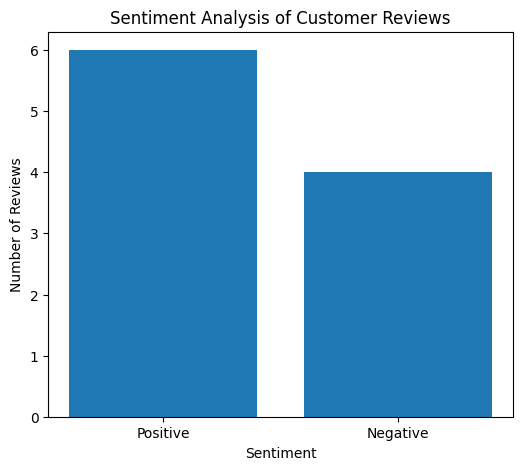

In [54]:
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Analysis of Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

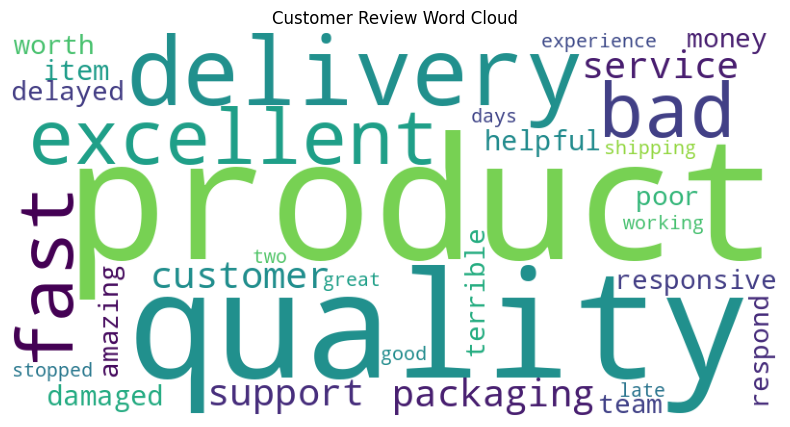

In [55]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Customer Review Word Cloud')
plt.show()

In [58]:
print("\nBusiness Insights")
print("------------------------------")

positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])

print("Total Positive Reviews :", positive_count)
print("Total Negative Reviews :", negative_count)

print("\nCommon Positive Areas:")
print("- Product quality")
print("- Fast delivery")
print("- Good customer service")

print("\nCommon Customer Complaints:")
print("- Delayed delivery")
print("- Damaged products")



Business Insights
------------------------------
Total Positive Reviews : 6
Total Negative Reviews : 4

Common Positive Areas:
- Product quality
- Fast delivery
- Good customer service

Common Customer Complaints:
- Delayed delivery
- Damaged products
